# Decision Point Velocity Analysis

Classify every internal decision node (non-leaf, non R/L5XX) as **IMPORTANT** or **NON-IMPORTANT** based on the graph structure and current reward port configuration, then compare:
- Dwell time (frames / seconds) at the decision node
- Arrival speed (px/s) in a ±0.5 s window around the node visit

**IMPORTANT node**: from the current traversal direction, both forward branches lead to subtrees containing at least one reward port (real goal).  
**NON-IMPORTANT node**: only one forward branch leads to a reward port; the other is a dead-end (non-reward leaf).

Going-back events (mouse returns to the direction it came from) are counted but excluded from the main analysis.

### Within-patch dwelling
Patch pairs (by Target index): [1,2], [3,4], [5,6], [7,8].  
The **within-patch IMPORTANT node** is the graph node that separates the two goals of the same patch.  
A secondary analysis tests whether dwell time at these nodes differs when the mouse is about to **stay in patch** (cycle to the other port of the same pair) vs **leave the patch** (head toward a port from a different pair).

In [ ]:
import ast
import importlib.util
import pickle
import re
import sys
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

# Import speed_analysis directly from file to avoid omegaconf dependency
_sa_path = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/navigraph/analysis/speed_analysis.py')
_spec = importlib.util.spec_from_file_location("speed_analysis", _sa_path)
_mod  = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
compute_path_speed = _mod.compute_path_speed

# ── paths & constants ──────────────────────────────────────────────────────────
BASE_DIR     = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs')
GRAPH_PKL    = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/FullMazeGrid.pkl')
FPS          = 40.0
FRAME_COL    = ('frame_idx_global', '')
X_COL        = ('headstage', 'x')
Y_COL        = ('headstage', 'y')
SMOOTH_WIN   = 5           # frames for speed smoothing (passed to compute_path_speed)
VEL_WIN_S    = 0.25        # half-window in seconds for speed window around node (total = 0.5s)
VEL_WIN_FR   = int(VEL_WIN_S * FPS)  # = 10 frames

SESSIONS = sorted(
    [d.name for d in BASE_DIR.iterdir()
     if d.is_dir() and (d/'traversal_df.csv').exists() and (d/'summary_df.pkl').exists()]
)
print(f"{len(SESSIONS)} sessions found:", SESSIONS)

In [36]:
# ── Load graph G (same logic as change_of_mind.ipynb cell 4) ──────────────────
with open(GRAPH_PKL, 'rb') as f:
    mapping_data = pickle.load(f)

nodes_dict = mapping_data['mappings']['nodes']
edges_dict = mapping_data['mappings']['edges']

node_positions = {}
for node_id, polygon_list in nodes_dict.items():
    polygon = polygon_list[0] if polygon_list else []
    if polygon and len(polygon) >= 2:
        xs = [p[0] for p in polygon]
        ys = [p[1] for p in polygon]
        node_positions[node_id] = (sum(xs)/len(xs), sum(ys)/len(ys))

G = nx.DiGraph()
G.add_nodes_from(node_positions.keys())
for edge_key in edges_dict.keys():
    parts = edge_key.split('_')
    if len(parts) == 2:
        a, b = parts
        if a in node_positions and b in node_positions:
            G.add_edge(a, b)
            G.add_edge(b, a)

Gu = G.to_undirected()
print(f"Graph: {len(Gu.nodes())} nodes, {len(Gu.edges())} undirected edges")

# Leaf nodes: R/L5XX (reward or dead-end terminals — never decision points)
LEAF_RE = re.compile(r'^[RL]5\d+$')
leaf_nodes     = {n for n in Gu.nodes() if LEAF_RE.match(n)}
internal_nodes = {n for n in Gu.nodes() if not LEAF_RE.match(n)}

# Parent-of-leaf nodes: internal nodes that have at least one leaf neighbour.
# These are the L/R4XX nodes — they sit directly above the leaf layer.
# They are excluded from statistics entirely (like leaves), because any visit
# to them is either: (a) arrived from parent → trivially non-important (one
# branch goes to reward leaf, other to dead-end leaf) with no meaningful choice,
# or (b) arrived from a leaf → already excluded as a dead-end return.
parent_of_leaf_nodes = {n for n in internal_nodes
                        if any(LEAF_RE.match(nb) for nb in Gu.neighbors(n))}

# True decision nodes: the nodes that actually enter the statistics
decision_nodes = internal_nodes - parent_of_leaf_nodes

print(f"Leaf nodes        (R/L5XX, excluded):         {len(leaf_nodes)}")
print(f"Parent-of-leaf    (R/L4XX, excluded):         {len(parent_of_leaf_nodes)}")
print(f"True decision nodes (enter statistics):        {len(decision_nodes)}")

Graph: 126 nodes, 125 undirected edges
Leaf nodes        (R/L5XX, excluded):         64
Parent-of-leaf    (R/L4XX, excluded):         32
True decision nodes (enter statistics):        30


In [37]:
# ── Port maps and patch definitions (from change_of_mind.ipynb cell 5) ─────────
# Switch date: after 07/09/2025 R59↔R55 for Target7/Target8.
PORT_MAP_BEFORE = {
    'R522': 'Target1', 'R526': 'Target2',
    'L56':  'Target3', 'L510': 'Target4',
    'L521': 'Target5', 'L525': 'Target6',
    'R55':  'Target7', 'R59':  'Target8',
}
PORT_MAP_AFTER = {
    'R522': 'Target1', 'R526': 'Target2',
    'L56':  'Target3', 'L510': 'Target4',
    'L521': 'Target5', 'L525': 'Target6',
    'R59':  'Target7', 'R55':  'Target8',
}

# Patch pairs: Target number pairs that share a physical arm
PATCH_PAIRS = [(1, 2), (3, 4), (5, 6), (7, 8)]

def get_port_map(session_name: str) -> dict:
    dd, mm, yyyy = session_name.split('_')
    if mm == '09' and int(dd) >= 7:
        return PORT_MAP_AFTER
    return PORT_MAP_BEFORE

# Within-patch IMPORTANT nodes: the graph junction that separates the two goals
# of each patch.  These are the same regardless of the R55/R59 label swap.
#
#  Patch (1,2): R522 and R526 → both reachable via R11 (children R22, R23)
#  Patch (3,4): L56  and L510 → both reachable via L10 (children L20, L21)
#  Patch (5,6): L521 and L525 → both reachable via L11 (children L22, L23)
#  Patch (7,8): R59  and R55  → both reachable via R10 (children R20, R21)
WITHIN_PATCH_INFO = {
    'R11': {'patch': (1, 2), 'patch_children': {'R22', 'R23'}, 'parent': 'R0'},
    'L10': {'patch': (3, 4), 'patch_children': {'L20', 'L21'}, 'parent': 'L0'},
    'L11': {'patch': (5, 6), 'patch_children': {'L22', 'L23'}, 'parent': 'L0'},
    'R10': {'patch': (7, 8), 'patch_children': {'R20', 'R21'}, 'parent': 'R0'},
}
WITHIN_PATCH_NODES = set(WITHIN_PATCH_INFO.keys())

# Helper: which patch (1-indexed) does a target number belong to?
def target_to_patch(target_num: int) -> tuple:
    for pair in PATCH_PAIRS:
        if target_num in pair:
            return pair
    return None

print("Port maps and patch definitions loaded.")
print("Within-patch IMPORTANT nodes:", sorted(WITHIN_PATCH_NODES))

Port maps and patch definitions loaded.
Within-patch IMPORTANT nodes: ['L10', 'L11', 'R10', 'R11']


In [38]:
# ── Decision node classifier ───────────────────────────────────────────────────

def subtree_reward_nodes(start_child: str, barrier_node: str, reward_set: set) -> set:
    """BFS from start_child away from barrier_node; return reward nodes found."""
    seen = {barrier_node}
    queue = [start_child]
    found = set()
    while queue:
        n = queue.pop(0)
        if n in seen:
            continue
        seen.add(n)
        if n in reward_set:
            found.add(n)
        for nb in Gu.neighbors(n):
            if nb not in seen:
                queue.append(nb)
    return found


def classify_decision(node: str, came_from: str, reward_set: set) -> str | None:
    """
    Returns 'important', 'non_important', or None.
    Returns None for: leaf nodes, parent-of-leaf nodes, leaf arrivals, degree-2 nodes.
    """
    if LEAF_RE.match(node):
        return None
    if node in parent_of_leaf_nodes:
        return None   # excluded entirely like leaves
    if LEAF_RE.match(came_from):
        return None   # arrived from dead-end leaf — excluded like going-back
    children = [n for n in Gu.neighbors(node) if n != came_from]
    if len(children) < 2:
        return None

    child_has_reward = [
        len(subtree_reward_nodes(child, node, reward_set)) > 0
        for child in children
    ]
    if all(child_has_reward):
        return 'important'
    if any(child_has_reward):
        return 'non_important'
    return None


# ── Structural summary over true decision nodes only ───────────────────────────
reward_set_after = set(PORT_MAP_AFTER.keys())

always_imp    = set()
sometimes_imp = set()
never_imp     = set()

for n in sorted(decision_nodes):   # parent_of_leaf_nodes excluded here
    results = set()
    for came_from in Gu.neighbors(n):
        c = classify_decision(n, came_from, reward_set_after)
        if c:
            results.add(c)
    if not results:
        never_imp.add(n)
    elif results == {'important'}:
        always_imp.add(n)
    elif 'important' in results:
        sometimes_imp.add(n)
    else:
        never_imp.add(n)

print("ALWAYS IMPORTANT:  ", sorted(always_imp))
print(f"SOMETIMES IMPORTANT: {len(sometimes_imp)} nodes")
print(f"NEVER IMPORTANT:     {len(never_imp)} nodes")
print(f"EXCLUDED (parent-of-leaf, like leaves): {len(parent_of_leaf_nodes)} nodes")
print()
print("Within-patch nodes ∩ always-important:", WITHIN_PATCH_NODES & always_imp)
print("Between-patch always-important nodes:",  sorted(always_imp - WITHIN_PATCH_NODES))

ALWAYS IMPORTANT:   ['L0', 'L10', 'L11', 'R0', 'R10', 'R11']
SOMETIMES IMPORTANT: 16 nodes
NEVER IMPORTANT:     8 nodes
EXCLUDED (parent-of-leaf, like leaves): 32 nodes

Within-patch nodes ∩ always-important: {'L11', 'R10', 'R11', 'L10'}
Between-patch always-important nodes: ['L0', 'R0']


In [39]:
# ── Per-direction summary for every 'sometimes important' node ─────────────────
# For each node that is IMPORTANT only in some traversal directions, show:
#   • which 'came_from' neighbour makes it IMPORTANT (***) vs NON-IMPORTANT
#   • for each of the two forward branches: which reward Targets are reachable
#
# Leaf arrivals (came_from = R/L5XX) are excluded — same filter as classify_decision.
# L/R4XX nodes no longer appear here because their only "important" direction
# was from a leaf child and is now excluded.

node_to_target = PORT_MAP_AFTER
target_short   = {v: v.replace('Target', 'T') for v in PORT_MAP_AFTER.values()}

def branch_target_str(node, came_from, rs):
    """Return list of (child_node, [short_target_labels]) for the two forward branches."""
    children = [n for n in Gu.neighbors(node) if n != came_from]
    out = []
    for child in children:
        rw     = subtree_reward_nodes(child, node, rs)
        labels = sorted(target_short[node_to_target[r]] for r in rw if r in node_to_target)
        out.append((child, labels))
    return out

rows = []
for n in sorted(sometimes_imp):
    for came_from in sorted(Gu.neighbors(n)):
        if LEAF_RE.match(came_from):
            continue   # exclude leaf arrivals, consistent with classify_decision
        cls = classify_decision(n, came_from, reward_set_after)
        if cls is None:
            continue
        branches = branch_target_str(n, came_from, reward_set_after)
        rows.append({
            'node':             n,
            'came_from':        came_from,
            'classification':   cls,
            'branch_A':         branches[0][0],
            'branch_A_targets': ', '.join(branches[0][1]) if branches[0][1] else '—',
            'branch_B':         branches[1][0],
            'branch_B_targets': ', '.join(branches[1][1]) if branches[1][1] else '—',
        })

df_sometimes = pd.DataFrame(rows)

# ── Tabular display ────────────────────────────────────────────────────────────
W = 95
print('=' * W)
print('SOMETIMES-IMPORTANT nodes — per-direction classification  (port map: after 07/09/2025)')
print('Leaf arrivals excluded. L/R4XX nodes (parents of leaves) are now NEVER IMPORTANT.')
print('=' * W)
print(f"{'Node':<6}  {'Came from':<10}  {'Classification':<16}  "
      f"{'Branch A → [targets]':<34}  Branch B → [targets]")
print('-' * W)

prev_node = None
for _, r in df_sometimes.iterrows():
    node_col = r['node'] if r['node'] != prev_node else ''
    marker   = '*** ' if r['classification'] == 'important' else '    '
    ba = f"{r['branch_A']} → [{r['branch_A_targets']}]"
    bb = f"{r['branch_B']} → [{r['branch_B_targets']}]"
    print(f"{node_col:<6}  from {r['came_from']:<7}  {marker}{r['classification']:<12}  {ba:<34}  {bb}")
    prev_node = r['node']

print()
print("*** = IMPORTANT direction (both forward branches reach ≥1 reward, arrived from non-leaf non-reward arm)")
print("      After 07/09: T7=R59, T8=R55.  Before 07/09: T7=R55, T8=R59 (only labels swap; structure identical)")

SOMETIMES-IMPORTANT nodes — per-direction classification  (port map: after 07/09/2025)
Leaf arrivals excluded. L/R4XX nodes (parents of leaves) are now NEVER IMPORTANT.
Node    Came from   Classification    Branch A → [targets]                Branch B → [targets]
-----------------------------------------------------------------------------------------------
L20     from L10          non_important  L30 → [—]                           L31 → [T3]
        from L30      *** important     L10 → [T1, T2, T4, T5, T6, T7, T8]  L31 → [T3]
        from L31          non_important  L30 → [—]                           L10 → [T1, T2, T4, T5, T6, T7, T8]
L21     from L10          non_important  L33 → [—]                           L32 → [T4]
        from L32          non_important  L10 → [T1, T2, T3, T5, T6, T7, T8]  L33 → [—]
        from L33      *** important     L10 → [T1, T2, T3, T5, T6, T7, T8]  L32 → [T4]
L22     from L11          non_important  L34 → [—]                           L35 → [T5]
   

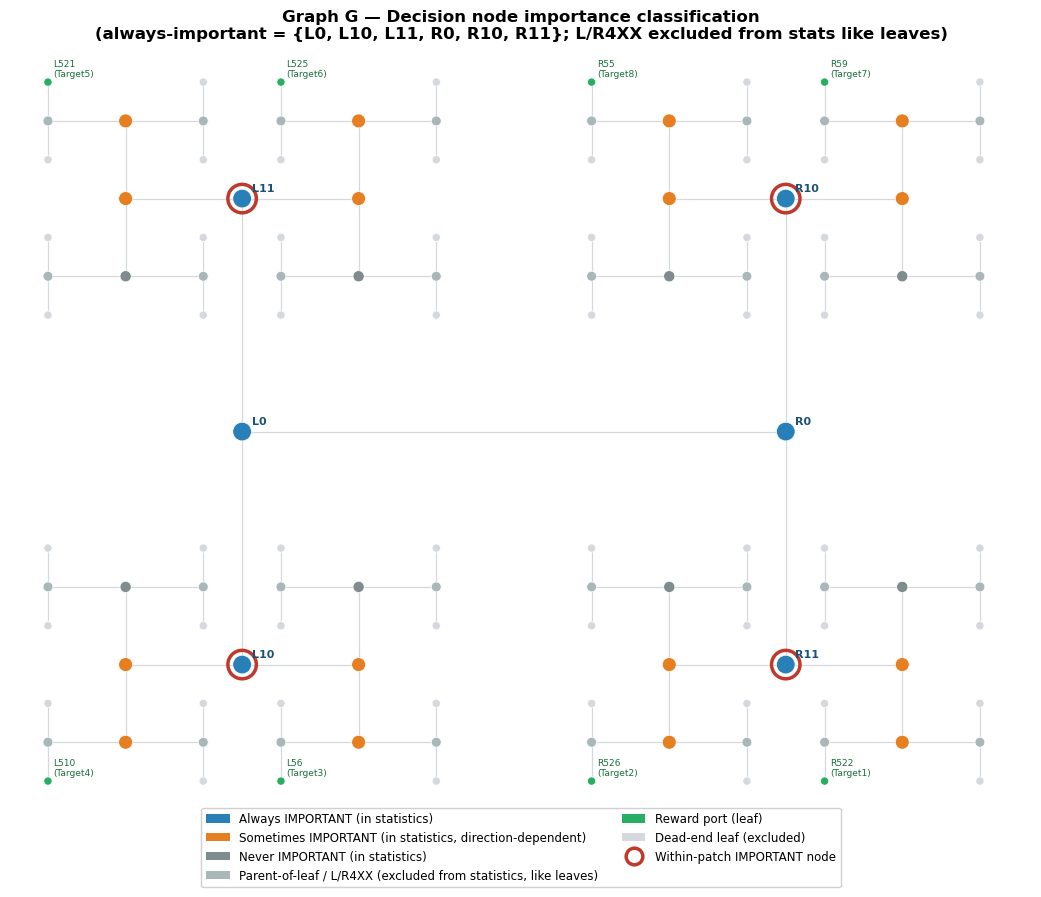

In [97]:
# ── Graph G: visualise node importance classification ─────────────────────────
C_ALWAYS       = '#2980b9'   # blue       – always IMPORTANT
C_SOMETIMES    = '#e67e22'   # orange     – sometimes IMPORTANT
C_NEVER        = '#7f8c8d'   # gray       – never IMPORTANT (true decision nodes)
C_POL          = '#aab7b8'   # light gray – parent-of-leaf (L/R4XX, excluded like leaves)
C_LEAF_RWD     = '#27ae60'   # green      – leaf that IS a reward port
C_LEAF_NORWD   = '#d5d8dc'   # very light – dead-end leaf, no reward
C_PATCH_RING   = '#c0392b'   # red ring   – within-patch IMPORTANT node

reward_leaves = set(PORT_MAP_AFTER.keys())

def node_style(n):
    if LEAF_RE.match(n):
        return (C_LEAF_RWD if n in reward_leaves else C_LEAF_NORWD, 35, 1)
    if n in parent_of_leaf_nodes:
        return (C_POL, 50, 2)          # excluded — shown but clearly muted
    if n in always_imp:
        return (C_ALWAYS, 180, 4)
    if n in sometimes_imp:
        return (C_SOMETIMES, 100, 3)
    return (C_NEVER, 65, 2)

fig, ax = plt.subplots(figsize=(15, 9))

for u, v in Gu.edges():
    if u in node_positions and v in node_positions:
        x0, y0 = node_positions[u]
        x1, y1 = node_positions[v]
        ax.plot([x0, x1], [y0, y1], '-', color='#d5d8dc', linewidth=0.9, zorder=1)

for layer in [C_LEAF_NORWD, C_LEAF_RWD, C_POL, C_NEVER, C_SOMETIMES, C_ALWAYS]:
    layer_nodes = [n for n in Gu.nodes()
                   if n in node_positions and node_style(n)[0] == layer]
    if not layer_nodes:
        continue
    xs    = [node_positions[n][0] for n in layer_nodes]
    ys    = [node_positions[n][1] for n in layer_nodes]
    sizes = [node_style(n)[1] for n in layer_nodes]
    ax.scatter(xs, ys, s=sizes, c=layer, zorder=node_style(layer_nodes[0])[2],
               edgecolors='white', linewidths=0.5)

for n in WITHIN_PATCH_NODES:
    if n in node_positions:
        x, y = node_positions[n]
        ax.scatter([x], [y], s=420, facecolors='none',
                   edgecolors=C_PATCH_RING, linewidths=2.5, zorder=5)

for n in sorted(always_imp):
    if n in node_positions:
        x, y = node_positions[n]
        ax.annotate(n, (x, y), textcoords='offset points', xytext=(7, 5),
                    fontsize=8, fontweight='bold', color='#1a5276', zorder=6)

label_map = {v: k for k, v in PORT_MAP_AFTER.items()}
for target, node in label_map.items():
    if node in node_positions:
        x, y = node_positions[node]
        ax.annotate(f"{node}\n({target})", (x, y),
                    textcoords='offset points', xytext=(4, 4),
                    fontsize=6.5, color='#196f3d', zorder=6)

from matplotlib.lines import Line2D
legend_elements = [
    mpatches.Patch(facecolor=C_ALWAYS,    label='Always IMPORTANT (in statistics)'),
    mpatches.Patch(facecolor=C_SOMETIMES, label='Sometimes IMPORTANT (in statistics, direction-dependent)'),
    mpatches.Patch(facecolor=C_NEVER,     label='Never IMPORTANT (in statistics)'),
    mpatches.Patch(facecolor=C_POL,       label='Parent-of-leaf / L/R4XX (excluded from statistics, like leaves)'),
    mpatches.Patch(facecolor=C_LEAF_RWD,  label='Reward port (leaf)'),
    mpatches.Patch(facecolor=C_LEAF_NORWD,label='Dead-end leaf (excluded)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
           markeredgecolor=C_PATCH_RING, markersize=12, markeredgewidth=2.5,
           label='Within-patch IMPORTANT node'),
]
ax.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=8.5,
          framealpha=0.92, bbox_to_anchor=(0.5, -0.1))

ax.set_title('Graph G — Decision node importance classification\n'
             '(always-important = {L0, L10, L11, R0, R10, R11}; '
             'L/R4XX excluded from stats like leaves)',
             fontsize=12, fontweight='bold')
ax.set_xlim(50, 900)
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# ── Graph G: same layout, node labels for all decision nodes ──────────────────
fig, ax = plt.subplots(figsize=(15, 9))

for u, v in Gu.edges():
    if u in node_positions and v in node_positions:
        x0, y0 = node_positions[u]
        x1, y1 = node_positions[v]
        ax.plot([x0, x1], [y0, y1], '-', color='#d5d8dc', linewidth=0.9, zorder=1)

for layer in [C_LEAF_NORWD, C_LEAF_RWD, C_POL, C_NEVER, C_SOMETIMES, C_ALWAYS]:
    layer_nodes = [n for n in Gu.nodes()
                   if n in node_positions and node_style(n)[0] == layer]
    if not layer_nodes:
        continue
    xs    = [node_positions[n][0] for n in layer_nodes]
    ys    = [node_positions[n][1] for n in layer_nodes]
    sizes = [node_style(n)[1] for n in layer_nodes]
    ax.scatter(xs, ys, s=sizes, c=layer, zorder=node_style(layer_nodes[0])[2],
               edgecolors='white', linewidths=0.5)

# Label every decision node (not leaf, not parent-of-leaf)
for n in sorted(decision_nodes):
    if n not in node_positions:
        continue
    x, y = node_positions[n]
    ax.annotate(
        n, (x, y),
        textcoords='offset points', xytext=(0, 7),
        fontsize=8.5, fontweight='bold',
        color='black',
        ha='center',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.75),
        zorder=7,
    )

# Label reward leaf nodes (green dots) with node name and Target
label_map = {v: k for k, v in PORT_MAP_AFTER.items()}
for target, node in label_map.items():
    if node in node_positions:
        x, y = node_positions[node]
        ax.annotate(f"{node}\n({target})", (x, y),
                    textcoords='offset points', xytext=(4, 4),
                    fontsize=6.5, color='#196f3d', zorder=6)

from matplotlib.lines import Line2D
legend_elements = [
    mpatches.Patch(facecolor=C_ALWAYS,    label='Always IMPORTANT'),
    mpatches.Patch(facecolor=C_SOMETIMES, label='Sometimes IMPORTANT'),
    mpatches.Patch(facecolor=C_NEVER,     label='Never IMPORTANT'),
    mpatches.Patch(facecolor=C_POL,       label='Parent-of-leaf / L/R4XX (excluded)'),
    mpatches.Patch(facecolor=C_LEAF_RWD,  label='Reward port (leaf)'),
    mpatches.Patch(facecolor=C_LEAF_NORWD,label='Dead-end leaf'),
]
ax.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=8.5,
          framealpha=0.92, bbox_to_anchor=(0.5, -0.08))

ax.set_title('Graph G — Decision node labels\n'
             '(labels shown for all 30 true decision nodes; leaves and L/R4XX unlabelled)',
             fontsize=12, fontweight='bold')
ax.set_xlim(50, 900)
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()

In [41]:
# ── Parse adjacent neighbor from traversal_df row ─────────────────────────────

def adjacent_neighbor(all_rows: pd.DataFrame, idx: int, direction: str, current_node: str):
    """Return the neighbor node adjacent to traversal row idx in given direction."""
    adj_idx = idx - 1 if direction == 'prev' else idx + 1
    if adj_idx < 0 or adj_idx >= len(all_rows):
        return None
    adj = all_rows.iloc[adj_idx]
    if adj['location_type'] == 'node':
        return adj['headstage_graph_node']
    if adj['location_type'] == 'edge':
        try:
            a, b = ast.literal_eval(str(adj['headstage_graph_edge']))
            if a == current_node:
                return b
            if b == current_node:
                return a
        except Exception:
            pass
    return None


# ── Process one session: classify each decision-node visit ────────────────────

def process_session(session_name: str) -> tuple[pd.DataFrame, int, int]:
    """
    Returns (visits_df, n_goback, n_from_leaf).
    Excluded entirely: leaf nodes, parent-of-leaf nodes, going-back events,
                       visits where came_from is a leaf.
    """
    port_map   = get_port_map(session_name)
    reward_set = set(port_map.keys())

    trav = pd.read_csv(BASE_DIR / session_name / 'traversal_df.csv')
    trav = trav.reset_index(drop=True)

    rows        = []
    n_goback    = 0
    n_from_leaf = 0

    for idx in range(len(trav)):
        row = trav.iloc[idx]
        if row['location_type'] != 'node':
            continue
        node = row['headstage_graph_node']
        if not isinstance(node, str):
            continue
        # Skip leaf nodes and parent-of-leaf nodes (L/R4XX) entirely
        if LEAF_RE.match(node) or node in parent_of_leaf_nodes:
            continue

        came_from = adjacent_neighbor(trav, idx, 'prev', node)
        went_to   = adjacent_neighbor(trav, idx, 'next', node)

        # Going-back: mouse returns toward where it came from
        if came_from is not None and went_to is not None and came_from == went_to:
            n_goback += 1
            continue

        if came_from is None:
            continue

        # Arrived from a dead-end leaf — equivalent to going-back from a dead end
        if LEAF_RE.match(came_from):
            n_from_leaf += 1
            continue

        classification = classify_decision(node, came_from, reward_set)
        if classification is None:
            continue

        rows.append({
            'session':         session_name,
            'node':            node,
            'came_from':       came_from,
            'went_to':         went_to,
            'classification':  classification,
            'trial_idx':       int(row['trial_idx']) if pd.notna(row['trial_idx']) else -1,
            'start_frame':     int(row['start_frame_global']),
            'end_frame':       int(row['end_frame_global']),
            'dwell_frames':    int(row['duration']),
            'dwell_s':         float(row['duration']) / FPS,
            'is_inferred':     bool(row['is_inferred']),
            'is_within_patch': node in WITHIN_PATCH_NODES,
        })

    return pd.DataFrame(rows), n_goback, n_from_leaf


print("Helper functions defined. Processing all sessions ...")

Helper functions defined. Processing all sessions ...


In [42]:
# ── Run traversal classification for all sessions ─────────────────────────────
all_visits       = []
goback_stats     = {}
from_leaf_stats  = {}

for sess in SESSIONS:
    visits_df, n_gb, n_fl = process_session(sess)
    all_visits.append(visits_df)
    goback_stats[sess]    = n_gb
    from_leaf_stats[sess] = n_fl
    print(f"{sess}: {len(visits_df)} decision visits, {n_gb} going-back, {n_fl} from-leaf-dead-end (excluded)")

visits = pd.concat(all_visits, ignore_index=True)
print(f"\nTotal: {len(visits)} decision-node visits across {len(SESSIONS)} sessions.")
print(visits['classification'].value_counts())
print(f"\nTotal going-back events:   {sum(goback_stats.values())}")
print(f"Total from-leaf exclusions: {sum(from_leaf_stats.values())}")

09_09_2025: 2708 decision visits, 196 going-back, 5 from-leaf-dead-end (excluded)
10_09_2025: 3112 decision visits, 155 going-back, 0 from-leaf-dead-end (excluded)
11_09_2025: 3501 decision visits, 285 going-back, 0 from-leaf-dead-end (excluded)
12_08_2025: 3455 decision visits, 109 going-back, 0 from-leaf-dead-end (excluded)
13_08_2025: 3450 decision visits, 95 going-back, 0 from-leaf-dead-end (excluded)
14_08_2025: 4217 decision visits, 76 going-back, 0 from-leaf-dead-end (excluded)
18_08_2025: 4184 decision visits, 181 going-back, 0 from-leaf-dead-end (excluded)
19_08_2025: 3135 decision visits, 133 going-back, 0 from-leaf-dead-end (excluded)
20_08_2025: 3504 decision visits, 139 going-back, 0 from-leaf-dead-end (excluded)
21_08_2025: 3151 decision visits, 163 going-back, 1 from-leaf-dead-end (excluded)
24_08_2025: 2408 decision visits, 234 going-back, 0 from-leaf-dead-end (excluded)
27_08_2025: 3327 decision visits, 251 going-back, 1 from-leaf-dead-end (excluded)

Total: 40152 deci

In [43]:
# ── Compute velocity at each decision-node visit (session-by-session) ──────────
# Uses a ±VEL_WIN_S window centred on the node visit to ensure enough frames
# even for single-frame node dwell times.

speed_cols = []   # will be one list per visit (NaN if no tracking data)

for sess in SESSIONS:
    sess_mask = visits['session'] == sess
    if not sess_mask.any():
        continue

    with open(BASE_DIR / sess / 'summary_df.pkl', 'rb') as f:
        summary_df = pickle.load(f)

    # Determine max frame available
    fc = summary_df[FRAME_COL]
    max_frame = int(fc.max())

    sess_visits = visits[sess_mask]
    speeds = np.full(len(sess_visits), np.nan)

    for i, (_, row) in enumerate(sess_visits.iterrows()):
        mid  = (row['start_frame'] + row['end_frame']) // 2
        sf   = max(0, mid - VEL_WIN_FR)
        ef   = min(max_frame, mid + VEL_WIN_FR)
        try:
            _, speed, _ = compute_path_speed(
                summary_df, sf, ef,
                fps=FPS, x_col=X_COL, y_col=Y_COL, frame_col=FRAME_COL,
                smooth_window_frames=SMOOTH_WIN,
            )
            if len(speed) > 0:
                speeds[i] = np.nanmean(speed)
        except Exception:
            pass

    speed_cols.append(pd.Series(speeds, index=sess_visits.index))
    print(f"{sess}: {np.sum(~np.isnan(speeds))}/{len(speeds)} speed values computed")
    del summary_df  # free memory

visits['mean_speed_pxs'] = pd.concat(speed_cols).reindex(visits.index)
print(f"\nSpeed data coverage: {visits['mean_speed_pxs'].notna().sum()}/{len(visits)} visits")

09_09_2025: 2708/2708 speed values computed
10_09_2025: 3112/3112 speed values computed
11_09_2025: 3501/3501 speed values computed
12_08_2025: 3455/3455 speed values computed
13_08_2025: 3450/3450 speed values computed
14_08_2025: 4217/4217 speed values computed
18_08_2025: 4184/4184 speed values computed
19_08_2025: 3135/3135 speed values computed
20_08_2025: 3504/3504 speed values computed
21_08_2025: 3151/3151 speed values computed
24_08_2025: 2408/2408 speed values computed
27_08_2025: 3327/3327 speed values computed

Speed data coverage: 40152/40152 visits


In [ ]:
# ── Summary statistics: IMPORTANT vs NON-IMPORTANT ────────────────────────────
# Inferred rows are excluded: their dwell time is the full gap between real
# detections, which inflates dwell and compresses speed artifactually.
visits_clean = visits[~visits['is_inferred']].copy()

n_total   = len(visits)
n_inferred = visits['is_inferred'].sum()
print(f"Inferred rows excluded: {n_inferred}/{n_total} "
      f"({100*n_inferred/n_total:.1f}%)")
print(f"Remaining for analysis: {len(visits_clean)}\n")

def summary_stats(series, label):
    s = series.dropna()
    return {'label': label, 'n': len(s),
            'mean': s.mean(), 'median': s.median(),
            'std': s.std(), 'sem': s.sem()}

groups = visits_clean.groupby('classification')
print("=" * 60)
print("Dwell time (seconds)")
for cls, grp in groups:
    st = summary_stats(grp['dwell_s'], cls)
    print(f"  {cls:14s}: n={st['n']:5d}  mean={st['mean']:.4f}s  median={st['median']:.4f}s  sem={st['sem']:.4f}")

print("\nMean speed (px/s) in ±{:.2f}s window".format(VEL_WIN_S))
for cls, grp in groups:
    st = summary_stats(grp['mean_speed_pxs'], cls)
    print(f"  {cls:14s}: n={st['n']:5d}  mean={st['mean']:.1f}  median={st['median']:.1f}  sem={st['sem']:.2f}")

# Mann-Whitney U tests
imp  = visits_clean[visits_clean['classification'] == 'important']
nimp = visits_clean[visits_clean['classification'] == 'non_important']

print("\nMann-Whitney U  (IMPORTANT vs NON-IMPORTANT)")
for col, lbl in [('dwell_s', 'Dwell time'), ('mean_speed_pxs', 'Speed')]:
    a = imp[col].dropna()
    b = nimp[col].dropna()
    if len(a) > 1 and len(b) > 1:
        u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
        print(f"  {lbl}: U={u:.0f}, p={p:.4g}")

/tmp/ipykernel_89300/3057673496.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['IMPORTANT', 'NON-IMPORTANT'], fontsize=10)
/tmp/ipykernel_89300/3057673496.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['IMPORTANT', 'NON-IMPORTANT'], fontsize=10)


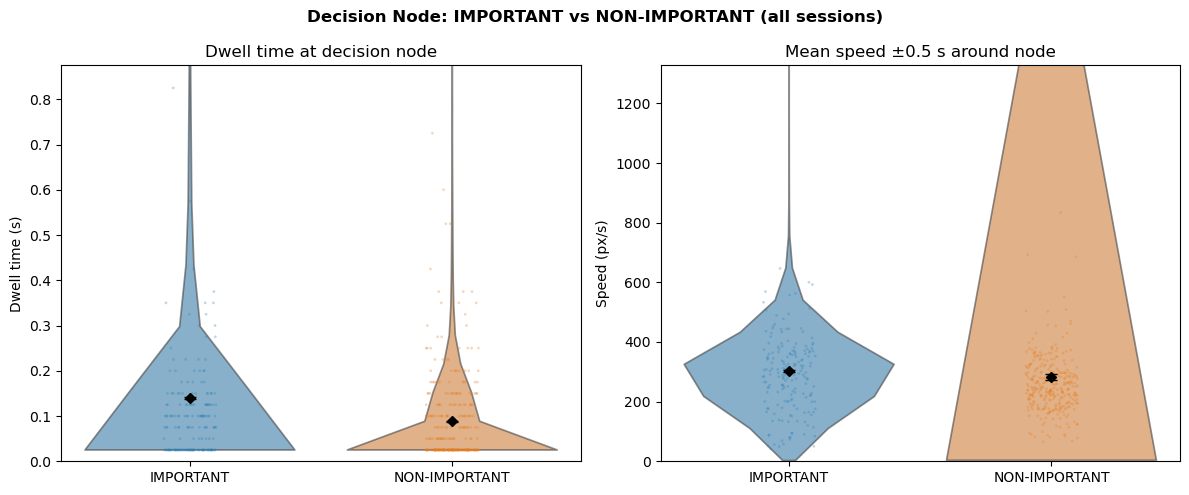

In [65]:
# ── Plot 1: Dwell time and speed — IMPORTANT vs NON-IMPORTANT ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
palette = {'important': '#2980b9', 'non_important': '#e67e22'}
order   = ['important', 'non_important']

for ax, col, ylabel, title in [
    (axes[0], 'dwell_s',         'Dwell time (s)',  'Dwell time at decision node'),
    (axes[1], 'mean_speed_pxs',  'Speed (px/s)',    f'Mean speed ±{VEL_WIN_S:.1f} s around node'),
]:
    plot_df = visits_clean[visits_clean[col].notna()].copy()

    sns.violinplot(
        data=plot_df, x='classification', y=col, order=order,
        palette=palette, inner=None, cut=0, ax=ax, alpha=0.6, hue='classification'
    )
    sns.stripplot(
        data=plot_df.sample(min(500, len(plot_df)), random_state=0),
        x='classification', y=col, order=order,
        palette=palette, size=2, alpha=0.3, jitter=True, ax=ax, hue='classification'
    )
    # Overlay mean ± SEM per group
    for xi, cls in enumerate(order):
        vals = plot_df[plot_df['classification'] == cls][col]
        ax.errorbar(xi, vals.mean(), yerr=vals.sem(), fmt='D',
                    color='black', ms=5, capsize=4, zorder=10, label='mean±SEM')

    ax.set_xticklabels(['IMPORTANT', 'NON-IMPORTANT'], fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(bottom=0, top=vals.quantile(0.995))

fig.suptitle('Decision Node: IMPORTANT vs NON-IMPORTANT (all sessions)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Plot: Inferred vs real split — artifact check ──────────────────────────────
# Uses the full `visits` (before inferred exclusion) to show the artifact.
# All other analyses below use visits_clean = visits[~is_inferred].

order_4   = ['important\n(real)', 'important\n(inferred)',
             'non_important\n(real)', 'non_important\n(inferred)']
palette_4 = {
    'important\n(real)':         '#2980b9',
    'important\n(inferred)':     '#a9cce3',
    'non_important\n(real)':     '#e67e22',
    'non_important\n(inferred)': '#fad7a0',
}

visits_artifact = visits.copy()
visits_artifact['_cls_inf'] = (
    visits_artifact['classification'] + '\n('
    + visits_artifact['is_inferred'].map({True: 'inferred', False: 'real'}) + ')'
)

print("Counts per group (all visits, including inferred):")
print(visits_artifact['_cls_inf'].value_counts().reindex(order_4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, ylabel, title in [
    (axes[0], 'dwell_s',        'Dwell time (s)',
     'Dwell time: inferred vs real nodes'),
    (axes[1], 'mean_speed_pxs', f'Speed (px/s)  [±{VEL_WIN_S:.2f}s window]',
     'Speed: inferred vs real nodes'),
]:
    plot_df = visits_artifact[visits_artifact[col].notna() &
                               visits_artifact['_cls_inf'].isin(order_4)].copy()
    sns.violinplot(
        data=plot_df, x='_cls_inf', y=col, order=order_4,
        palette=palette_4, inner=None, cut=0, ax=ax, alpha=0.6, hue='_cls_inf',
        legend=False,
    )
    for xi, grp in enumerate(order_4):
        vals = plot_df[plot_df['_cls_inf'] == grp][col]
        if len(vals) > 0:
            ax.errorbar(xi, vals.mean(), yerr=vals.sem() if len(vals) > 1 else 0,
                        fmt='D', color='black', ms=5, capsize=4, zorder=10)
    ax.set_xticklabels(['IMP\n(real)', 'IMP\n(inferred)',
                         'NON-IMP\n(real)', 'NON-IMP\n(inferred)'], fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(bottom=0, top=plot_df[col].quantile(0.995))

fig.suptitle('Inferred vs real node visits — artifact check\n'
             '(inferred rows are excluded from all other analyses)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Dwell time (mean / median / sem / n) by classification × inferred ===")
print(visits_artifact.groupby(['classification', 'is_inferred'])['dwell_s']
      .agg(['mean', 'median', 'sem', 'count']).round(4))
print("\n=== Speed by classification × inferred ===")
print(visits_artifact.groupby(['classification', 'is_inferred'])['mean_speed_pxs']
      .agg(['mean', 'median', 'sem', 'count']).round(2))

In [ ]:
# ── Plot: Progress across sessions (chronological) ─────────────────────────────
# Show how dwell time and speed evolve day-by-day, split by importance classification.
from datetime import datetime

def session_to_date(s):
    dd, mm, yyyy = s.split('_')
    return datetime(int(yyyy), int(mm), int(dd))

sessions_chron  = sorted(SESSIONS, key=session_to_date)
session_labels  = [s[:5] for s in sessions_chron]   # "DD_MM"

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
cls_style = {
    'important':     ('#2980b9', 'Important'),
    'non_important': ('#e67e22', 'Non-important'),
}

for ax, col, ylabel in [
    (axes[0], 'dwell_s',        'Mean dwell time (s)'),
    (axes[1], 'mean_speed_pxs', f'Mean speed (px/s)  [±{VEL_WIN_S:.2f}s window]'),
]:
    for cls, (color, label) in cls_style.items():
        ys   = []
        sems = []
        for sess in sessions_chron:
            vals = visits_clean[(visits_clean['session'] == sess) &
                                (visits_clean['classification'] == cls)][col].dropna()
            ys.append(vals.mean() if len(vals) > 0 else np.nan)
            sems.append(vals.sem()  if len(vals) > 1 else np.nan)
        ys   = np.array(ys,   dtype=float)
        sems = np.array(sems, dtype=float)
        xs = np.arange(len(sessions_chron))
        ax.plot(xs, ys, 'o-', color=color, label=label, ms=6, linewidth=2)
        ax.fill_between(xs, ys - sems, ys + sems, color=color, alpha=0.15)
    ax.set_ylabel(ylabel)
    ax.legend(loc='upper right')
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)

axes[1].set_xticks(range(len(sessions_chron)))
axes[1].set_xticklabels(session_labels, rotation=45, ha='right')
axes[1].set_xlabel('Session (chronological)')

fig.suptitle('Progress across sessions: dwell time and speed by node importance\n'
             '(mean ± SEM per session)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

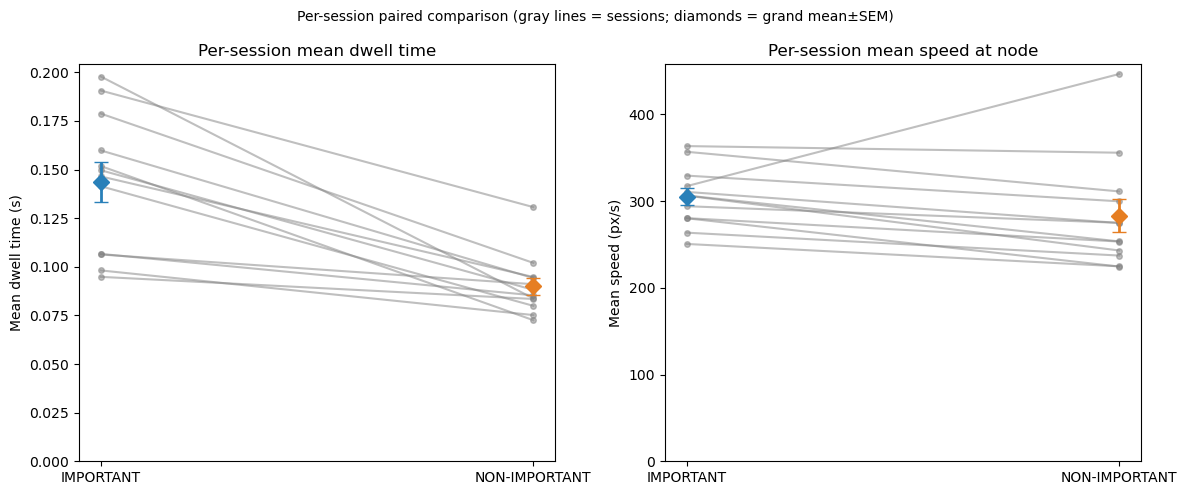

In [46]:
# ── Plot 2: Per-session mean dwell and speed (paired, to see consistency) ─────
sess_means = (
    visits_clean.groupby(['session', 'classification'])
    [['dwell_s', 'mean_speed_pxs']]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, ylabel, title in [
    (axes[0], 'dwell_s',        'Mean dwell time (s)',  'Per-session mean dwell time'),
    (axes[1], 'mean_speed_pxs', 'Mean speed (px/s)',    'Per-session mean speed at node'),
]:
    for sess in SESSIONS:
        sub = sess_means[sess_means['session'] == sess].set_index('classification')
        if 'important' in sub.index and 'non_important' in sub.index:
            ax.plot(
                ['IMPORTANT', 'NON-IMPORTANT'],
                [sub.loc['important', col], sub.loc['non_important', col]],
                'o-', color='gray', alpha=0.5, ms=4,
            )
    # Grand mean ± SEM across sessions
    for xi, cls in enumerate(['important', 'non_important']):
        vals = sess_means[sess_means['classification'] == cls][col].dropna()
        ax.errorbar(xi, vals.mean(), yerr=vals.sem(), fmt='D',
                    color=palette[cls], ms=8, capsize=5, zorder=10, linewidth=2)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['IMPORTANT', 'NON-IMPORTANT'])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(bottom=0)

fig.suptitle('Per-session paired comparison (gray lines = sessions; diamonds = grand mean±SEM)',
             fontsize=10)
plt.tight_layout()
plt.show()

---
## Within-patch dwelling: Stay vs Leave

For each visit to a **within-patch IMPORTANT node** (L10, L11, R10, R11), classify whether the mouse is:
- **Cycling** (staying in patch): came from one patch child → went to the other patch child  
- **Leaving** (exiting patch): came from a patch child → went toward the parent (= the rest of the tree)  
- **Arriving**: came from the parent direction (skip for this analysis)

Question: is dwell time longer (and/or speed lower) at the within-patch node when the mouse is about to leave the patch?

In [83]:
# ── Classify within-patch node visits: altering, leaving, or arriving ──────────
wp_visits = visits_clean[visits_clean['is_within_patch']].copy()

def classify_wp_visit(row) -> str | None:
    node     = row['node']
    came_from = row['came_from']
    went_to   = row['went_to']
    if node not in WITHIN_PATCH_INFO:
        return None
    info   = WITHIN_PATCH_INFO[node]
    parent = info['parent']
    patch_ch = info['patch_children']

    if came_from == parent:
        return 'arriving'   # mouse just came from outside the patch
    if came_from in patch_ch:
        if went_to in patch_ch:
            return 'altering'    # going to the other port in same patch
        if went_to == parent:
            return 'leaving'    # heading out of the patch
    return 'other'

wp_visits = wp_visits.copy()
wp_visits['wp_decision'] = wp_visits.apply(classify_wp_visit, axis=1)

print("Within-patch node visit types:")
print(wp_visits['wp_decision'].value_counts())
print("\nBreakdown by node:")
print(wp_visits.groupby(['node', 'wp_decision']).size().unstack(fill_value=0))

Within-patch node visit types:
wp_decision
altering    3697
arriving    2620
leaving     2594
other        198
Name: count, dtype: int64

Breakdown by node:
wp_decision  altering  arriving  leaving  other
node                                           
L10               772       400      403     36
L11               803       549      547     32
R10               952       724      720     35
R11              1170       947      924     95


In [89]:
# ── Statistics: altering vs leaving ────────────────────────────────────────────
alter_df = wp_visits[wp_visits['wp_decision'] == 'altering']
leave_df  = wp_visits[wp_visits['wp_decision'] == 'leaving']
arrive_df = wp_visits[wp_visits['wp_decision'] == 'arriving']

print("=" * 60)
print("Within-patch node: ALTERING vs LEAVING comparison")
print("=" * 60)

for col, lbl in [('dwell_s', 'Dwell time (s)'), ('mean_speed_pxs', 'Speed (px/s)')]:
    ca = alter_df[col].dropna()
    la = leave_df[col].dropna()
    aa = arrive_df[col].dropna()
    print(f"\n{lbl}")
    print(f"  Altering  n={len(ca):4d}  mean={ca.mean():.4f}  median={ca.median():.4f}  sem={ca.sem():.4f}")
    print(f"  Leaving  n={len(la):4d}  mean={la.mean():.4f}  median={la.median():.4f}  sem={la.sem():.4f}")
    print(f"  Arriving  n={len(aa):4d}  mean={aa.mean():.4f}  median={aa.median():.4f}  sem={aa.sem():.4f}")
    if len(ca) > 1 and len(la) > 1:
        u, p = stats.mannwhitneyu(ca, la, alternative='two-sided')
        print(f"  Mann-Whitney U={u:.0f}, p={p:.4g}")

Within-patch node: ALTERING vs LEAVING comparison

Dwell time (s)
  Altering  n=3697  mean=0.1538  median=0.1250  sem=0.0034
  Leaving  n=2594  mean=0.0950  median=0.0250  sem=0.0045
  Arriving  n=2620  mean=0.1451  median=0.0750  sem=0.0066
  Mann-Whitney U=7669115, p=0

Speed (px/s)
  Altering  n=3697  mean=318.7096  median=304.3958  sem=4.2951
  Leaving  n=2594  mean=286.3097  median=268.5928  sem=5.7562
  Arriving  n=2620  mean=274.6026  median=279.9873  sem=2.9933
  Mann-Whitney U=5777219, p=1.249e-43


/tmp/ipykernel_89300/1511619153.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Altering\n(stay in patch)', 'Leaving\n(exit patch)', 'Arriving\n(enter patch)'], fontsize=10)
/tmp/ipykernel_89300/1511619153.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Altering\n(stay in patch)', 'Leaving\n(exit patch)', 'Arriving\n(enter patch)'], fontsize=10)


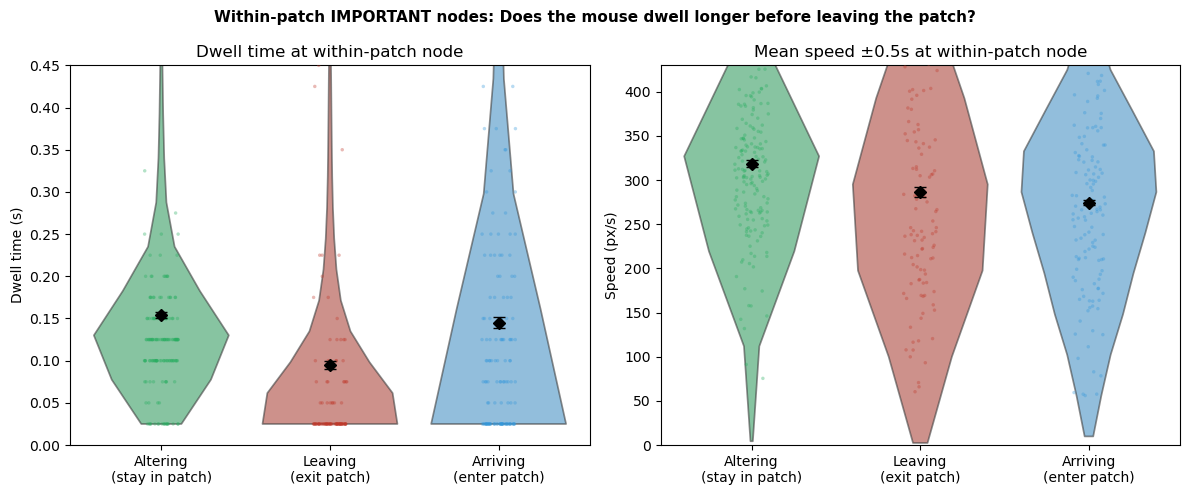

In [91]:
# ── Plot 3: Within-patch node — altering vs leaving ────────────────────────────
wp_plot_df = wp_visits[wp_visits['wp_decision'].isin(['altering', 'leaving', 'arriving'])].copy()
wp_palette = {'altering': '#27ae60', 'leaving': '#c0392b', 'arriving': '#3498db'}
wp_order   = ['altering', 'leaving', 'arriving']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, ylabel, title in [
    (axes[0], 'dwell_s',        'Dwell time (s)',   'Dwell time at within-patch node'),
    (axes[1], 'mean_speed_pxs', 'Speed (px/s)',     f'Mean speed ±{VEL_WIN_S:.1f}s at within-patch node'),
]:
    plot_df = wp_plot_df[wp_plot_df[col].notna()]
    sns.violinplot(
        data=plot_df, x='wp_decision', y=col, order=wp_order,
        palette=wp_palette, inner=None, cut=0, ax=ax, alpha=0.6, hue='wp_decision'
    )
    sns.stripplot(
        data=plot_df.sample(min(400, len(plot_df)), random_state=42),
        x='wp_decision', y=col, order=wp_order,
        palette=wp_palette, size=2.5, alpha=0.35, jitter=True, ax=ax, hue='wp_decision'
    )
    for xi, dec in enumerate(wp_order):
        vals = plot_df[plot_df['wp_decision'] == dec][col]
        ax.errorbar(xi, vals.mean(), yerr=vals.sem(), fmt='D',
                    color='black', ms=6, capsize=4, zorder=10)
    ax.set_xticklabels(['Altering\n(stay in patch)', 'Leaving\n(exit patch)', 'Arriving\n(enter patch)'], fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(bottom=0, top=vals.quantile(0.95))

fig.suptitle('Within-patch IMPORTANT nodes: Does the mouse dwell longer before leaving the patch?',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_89300/3863700779.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Altering', 'Leaving', 'Arriving'], fontsize=8)
/tmp/ipykernel_89300/3863700779.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Altering', 'Leaving', 'Arriving'], fontsize=8)
/tmp/ipykernel_89300/3863700779.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Altering', 'Leaving', 'Arriving'], fontsize=8)
/tmp/ipykernel_89300/3863700779.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Altering', 'Leaving', 'Arriving'], fontsize=8)


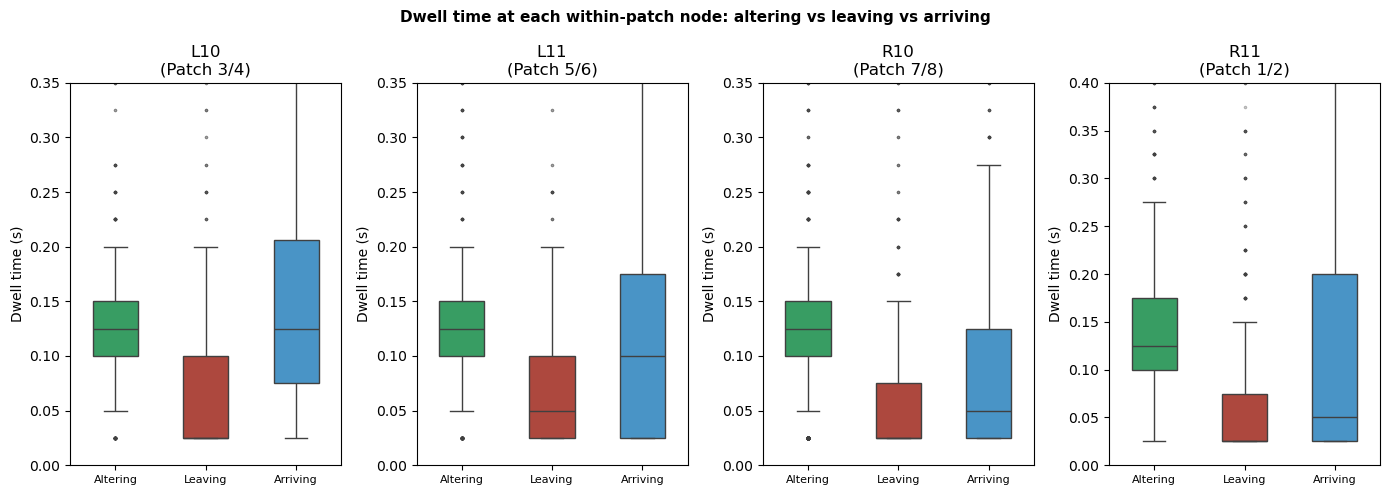

In [92]:
# ── Plot 4: Per-node breakdown — altering vs leaving dwell time ────────────────
fig, axes = plt.subplots(1, len(WITHIN_PATCH_NODES), figsize=(14, 5), sharey=False)

for ax, node in zip(axes, sorted(WITHIN_PATCH_NODES)):
    node_df = wp_plot_df[wp_plot_df['node'] == node]
    if node_df.empty:
        ax.set_title(node)
        continue
    info = WITHIN_PATCH_INFO[node]

    sns.boxplot(
        data=node_df[node_df['dwell_s'].notna()],
        x='wp_decision', y='dwell_s', order=wp_order,
        palette=wp_palette, ax=ax, width=0.5, hue='wp_decision', dodge=False,
        flierprops=dict(marker='.', ms=3, alpha=0.4),
    )
    patch_label = f"Patch {info['patch'][0]}/{info['patch'][1]}"
    ax.set_title(f"{node}\n({patch_label})")
    ax.set_xlabel('')
    ax.set_ylabel('Dwell time (s)')
    ax.set_xticklabels(['Altering', 'Leaving', 'Arriving'], fontsize=8)
    ax.set_ylim(bottom=0, top=node_df['dwell_s'].quantile(0.95))

fig.suptitle('Dwell time at each within-patch node: altering vs leaving vs arriving',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

Wilcoxon signed-rank (per-session paired means):


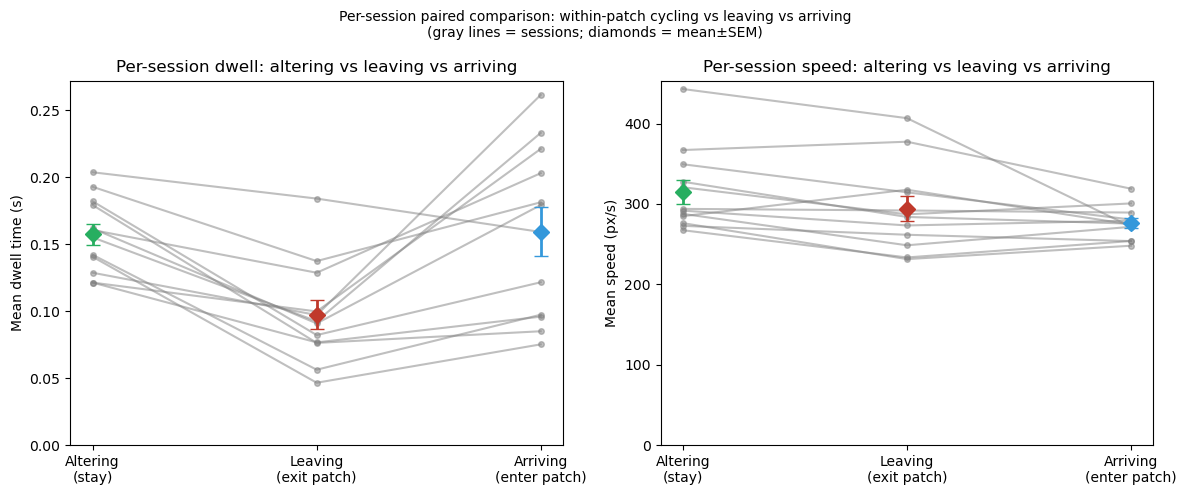

In [94]:
# ── Per-session paired test: within-patch altering vs leaving ──────────────────
sess_wp_means = (
    wp_visits[wp_visits['wp_decision'].isin(['altering', 'leaving', 'arriving'])]
    .groupby(['session', 'wp_decision'])
    [['dwell_s', 'mean_speed_pxs']]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, ylabel, title in [
    (axes[0], 'dwell_s',        'Mean dwell time (s)', 'Per-session dwell: altering vs leaving vs arriving'),
    (axes[1], 'mean_speed_pxs', 'Mean speed (px/s)',   'Per-session speed: altering vs leaving vs arriving'),
]:
    for sess in SESSIONS:
        sub = sess_wp_means[sess_wp_means['session'] == sess].set_index('wp_decision')
        if 'altering' in sub.index and 'leaving' in sub.index and 'arriving' in sub.index:
            ax.plot(
                ['Altering', 'Leaving', 'Arriving'],
                [sub.loc['altering', col], sub.loc['leaving', col], sub.loc['arriving', col]],
                'o-', color='gray', alpha=0.5, ms=4,
            )
    for xi, dec in enumerate(['altering', 'leaving', 'arriving']):
        vals = sess_wp_means[sess_wp_means['wp_decision'] == dec][col].dropna()
        ax.errorbar(xi, vals.mean(), yerr=vals.sem(), fmt='D',
                    color=wp_palette[dec], ms=8, capsize=5, zorder=10, linewidth=2)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['Altering\n(stay)', 'Leaving\n(exit patch)', 'Arriving\n(enter patch)'])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(bottom=0)

# Wilcoxon signed-rank test on per-session paired means
print("Wilcoxon signed-rank (per-session paired means):")
for col, lbl in [('dwell_s', 'Dwell time'), ('mean_speed_pxs', 'Speed')]:
    paired = []
    for sess in SESSIONS:
        sub = sess_wp_means[sess_wp_means['session'] == sess].set_index('wp_decision')
        if 'cycling' in sub.index and 'leaving' in sub.index and 'arriving' in sub.index:
            paired.append((sub.loc['cycling', col], sub.loc['leaving', col], sub.loc['arriving', col]))
    if len(paired) >= 4:
        cy_vals, lv_vals, ar_vals = zip(*[(p[0], p[1], p[2]) for p in paired if not (np.isnan(p[0]) or np.isnan(p[1]) or np.isnan(p[2]))])
        stat, p = stats.wilcoxon(cy_vals, lv_vals)
        print(f"  {lbl}: W={stat:.0f}, p={p:.4g}  (n={len(cy_vals)} sessions)")

fig.suptitle('Per-session paired comparison: within-patch cycling vs leaving vs arriving\n(gray lines = sessions; diamonds = mean±SEM)',
             fontsize=10)
plt.tight_layout()
plt.show()

---
## Sometimes-important nodes: same node, important vs non-important direction

For the 16 nodes that are **sometimes important** (classification depends on the direction of arrival), compare:
- Dwell time
- Speed in the ±0.5 s window

between visits where the traversal direction makes the node **IMPORTANT** vs **NON-IMPORTANT**.

This is a within-node paired design: we control for node identity and isolate the effect of traversal direction alone.

In [ ]:
# ── Sometimes-important nodes: important vs non-important direction ────────────
si_visits = visits_clean[visits_clean['node'].isin(sometimes_imp)].copy()

print(f"Sometimes-important nodes: {len(sometimes_imp)} nodes")
print(f"Total visits to these nodes: {len(si_visits)}")
print(si_visits['classification'].value_counts())
print()

# ── Overall statistics ─────────────────────────────────────────────────────────
print("=" * 65)
print("SOMETIMES-IMPORTANT nodes — important vs non-important direction")
print("=" * 65)

si_imp  = si_visits[si_visits['classification'] == 'important']
si_nimp = si_visits[si_visits['classification'] == 'non_important']

for col, lbl in [('dwell_s', 'Dwell time (s)'), ('mean_speed_pxs', 'Speed (px/s)')]:
    a = si_imp[col].dropna()
    b = si_nimp[col].dropna()
    print(f"\n{lbl}")
    print(f"  important     n={len(a):5d}  mean={a.mean():.4f}  median={a.median():.4f}  sem={a.sem():.4f}")
    print(f"  non_important n={len(b):5d}  mean={b.mean():.4f}  median={b.median():.4f}  sem={b.sem():.4f}")
    u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    print(f"  Mann-Whitney U={u:.0f}, p={p:.4g}")

# ── Overall violin plot ────────────────────────────────────────────────────────
si_palette = {'important': '#2980b9', 'non_important': '#e67e22'}
si_order   = ['important', 'non_important']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, ylabel, title in [
    (axes[0], 'dwell_s',        'Dwell time (s)',  'Dwell time'),
    (axes[1], 'mean_speed_pxs', 'Speed (px/s)',    f'Mean speed ±{VEL_WIN_S:.1f}s'),
]:
    plot_df = si_visits[si_visits[col].notna()]
    sns.violinplot(
        data=plot_df, x='classification', y=col, order=si_order,
        palette=si_palette, inner=None, cut=0, ax=ax, alpha=0.6, hue='classification',
    )
    sns.stripplot(
        data=plot_df.sample(min(600, len(plot_df)), random_state=7),
        x='classification', y=col, order=si_order,
        palette=si_palette, size=2, alpha=0.3, jitter=True, ax=ax, hue='classification',
    )
    for xi, cls in enumerate(si_order):
        vals = plot_df[plot_df['classification'] == cls][col]
        ax.errorbar(xi, vals.mean(), yerr=vals.sem(), fmt='D',
                    color='black', ms=6, capsize=4, zorder=10)
    ax.set_xticklabels(['IMPORTANT\ndirection', 'NON-IMPORTANT\ndirection'], fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(bottom=0, top=plot_df[col].quantile(0.995))

fig.suptitle('Sometimes-important nodes: same node, different traversal direction\n(all 16 nodes pooled)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Per-session paired means ───────────────────────────────────────────────────
si_sess_means = (
    si_visits.groupby(['session', 'classification'])
    [['dwell_s', 'mean_speed_pxs']]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, col, ylabel, title in [
    (axes[0], 'dwell_s',        'Mean dwell time (s)', 'Per-session mean dwell time'),
    (axes[1], 'mean_speed_pxs', 'Mean speed (px/s)',   'Per-session mean speed'),
]:
    paired_imp, paired_nimp = [], []
    for sess in SESSIONS:
        sub = si_sess_means[si_sess_means['session'] == sess].set_index('classification')
        if 'important' in sub.index and 'non_important' in sub.index:
            vi = sub.loc['important', col]
            vn = sub.loc['non_important', col]
            ax.plot(['IMPORTANT', 'NON-IMPORTANT'], [vi, vn], 'o-', color='gray', alpha=0.5, ms=4)
            paired_imp.append(vi)
            paired_nimp.append(vn)
    for xi, cls in enumerate(si_order):
        vals = si_sess_means[si_sess_means['classification'] == cls][col].dropna()
        ax.errorbar(xi, vals.mean(), yerr=vals.sem(), fmt='D',
                    color=si_palette[cls], ms=8, capsize=5, zorder=10, linewidth=2)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['IMPORTANT', 'NON-IMPORTANT'])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(bottom=0)

    if len(paired_imp) >= 4:
        stat, p = stats.wilcoxon(paired_imp, paired_nimp)
        print(f"Wilcoxon signed-rank ({lbl if 'dwell' in ylabel.lower() else 'Speed'}): "
              f"W={stat:.0f}, p={p:.4g}  (n={len(paired_imp)} sessions)")

fig.suptitle('Per-session paired comparison: sometimes-important nodes\n'
             '(gray lines = sessions; diamonds = grand mean±SEM)',
             fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# ── Per-node breakdown: important vs non-important direction ───────────────────
# 16 sometimes-important nodes — arrange in a 4×4 grid
nodes_sorted = sorted(sometimes_imp)
n_cols = 4
n_rows = int(np.ceil(len(nodes_sorted) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5), sharey=False)
axes_flat = axes.flatten()

for ax, node in zip(axes_flat, nodes_sorted):
    node_df = si_visits[si_visits['node'] == node]
    if node_df.empty:
        ax.set_visible(False)
        continue

    imp_vals  = node_df[node_df['classification'] == 'important']['mean_speed_pxs'].dropna()
    nimp_vals = node_df[node_df['classification'] == 'non_important']['mean_speed_pxs'].dropna()

    sns.boxplot(
        data=node_df[node_df['mean_speed_pxs'].notna()],
        x='classification', y='mean_speed_pxs', order=si_order,
        palette=si_palette, ax=ax, width=0.5, hue='classification', dodge=False,
        flierprops=dict(marker='.', ms=3, alpha=0.4),
    )
    for xi, vals in enumerate([imp_vals, nimp_vals]):
        ax.errorbar(xi, vals.mean(), yerr=vals.sem(), fmt='D',
                    color='black', ms=5, capsize=3, zorder=10)

    # Annotate with p-value if both groups have data
    if len(imp_vals) > 1 and len(nimp_vals) > 1:
        _, p = stats.mannwhitneyu(imp_vals, nimp_vals, alternative='two-sided')
        pstr = f'p={p:.3g}' if p >= 0.001 else f'p={p:.2e}'
        ax.set_title(f'{node}\n(n={len(imp_vals)}/{len(nimp_vals)},  {pstr})', fontsize=8)
    else:
        ax.set_title(node, fontsize=8)

    ax.set_xticklabels(['IMP', 'NON-IMP'], fontsize=8)
    ax.set_xlabel('')
    ax.set_ylabel('Speed (px/s)', fontsize=8)
    ax.set_ylim(bottom=0)

# Hide unused axes
for ax in axes_flat[len(nodes_sorted):]:
    ax.set_visible(False)

fig.suptitle('Sometimes-important nodes — per-node speed comparison\n'
             'IMPORTANT direction vs NON-IMPORTANT direction (boxes = IQR, diamonds = mean±SEM)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Same grid for dwell time ───────────────────────────────────────────────────
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5), sharey=False)
axes_flat = axes.flatten()

for ax, node in zip(axes_flat, nodes_sorted):
    node_df = si_visits[si_visits['node'] == node]
    if node_df.empty:
        ax.set_visible(False)
        continue

    imp_vals  = node_df[node_df['classification'] == 'important']['dwell_s'].dropna()
    nimp_vals = node_df[node_df['classification'] == 'non_important']['dwell_s'].dropna()

    sns.boxplot(
        data=node_df[node_df['dwell_s'].notna()],
        x='classification', y='dwell_s', order=si_order,
        palette=si_palette, ax=ax, width=0.5, hue='classification', dodge=False,
        flierprops=dict(marker='.', ms=3, alpha=0.4),
    )
    for xi, vals in enumerate([imp_vals, nimp_vals]):
        ax.errorbar(xi, vals.mean(), yerr=vals.sem(), fmt='D',
                    color='black', ms=5, capsize=3, zorder=10)

    if len(imp_vals) > 1 and len(nimp_vals) > 1:
        _, p = stats.mannwhitneyu(imp_vals, nimp_vals, alternative='two-sided')
        pstr = f'p={p:.3g}' if p >= 0.001 else f'p={p:.2e}'
        ax.set_title(f'{node}\n(n={len(imp_vals)}/{len(nimp_vals)},  {pstr})', fontsize=8)
    else:
        ax.set_title(node, fontsize=8)

    ax.set_xticklabels(['IMP', 'NON-IMP'], fontsize=8)
    ax.set_xlabel('')
    ax.set_ylabel('Dwell time (s)', fontsize=8)
    ax.set_ylim(bottom=0, top=node_df['dwell_s'].quantile(0.95))

for ax in axes_flat[len(nodes_sorted):]:
    ax.set_visible(False)

fig.suptitle('Sometimes-important nodes — per-node dwell time comparison\n'
             'IMPORTANT direction vs NON-IMPORTANT direction (boxes = IQR, diamonds = mean±SEM)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()